# **Multivariable Linear Regression Model**

In [16]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import random

In [17]:
df = pd.read_csv("data1.csv")
df.columns = ["w0", "medv", "age", "lstat"]
df.loc[:, "w0"] = 1
display(df.head(5))

x = df[["w0", "age", "lstat"]].to_numpy()
y = np.array(df["medv"])

display(x.shape, y.shape)
# display(x, y)

,w0,medv,age,lstat
0,1,24.0,65.2,4.98
1,1,21.6,78.9,9.14
2,1,34.7,61.1,4.03
3,1,33.4,45.8,2.94
4,1,36.2,54.2,5.33


(506, 3)

(506,)

In [18]:
# NORMALIZE DATA
r, c = x.shape
for j in range(1, c):
    # Get max and min of current column
    max_x = np.amax(x[:,j])         
    min_x = np.amin(x[:,j])
    
    x[:,j] = np.array([(e - min_x)/(max_x - min_x) for e in x[:,j]])

max_y = np.amax(y)
min_y = np.amin(y)
y = np.array([( e - min_y)/(max_y - min_y) for e in y])

display(x.shape, y.shape)
# display(x, y)

(506, 3)

(506,)

In [19]:
# 70% for train and 30% test
m, = y.shape
idx = np.array(np.arange(m))
include_idx = set(np.random.choice(idx, size = int(0.7*m), replace=False))
mask = np.array([(i in include_idx) for i in range(m)])

trainX = x[mask]
testX = x[~mask]

trainY = y[mask]
testY = y[~mask]

display(trainX.shape, testX.shape)
display(trainY.shape, testY.shape)

(354, 3)

(152, 3)

(354,)

(152,)

Text(0.5, 0, 'medv')

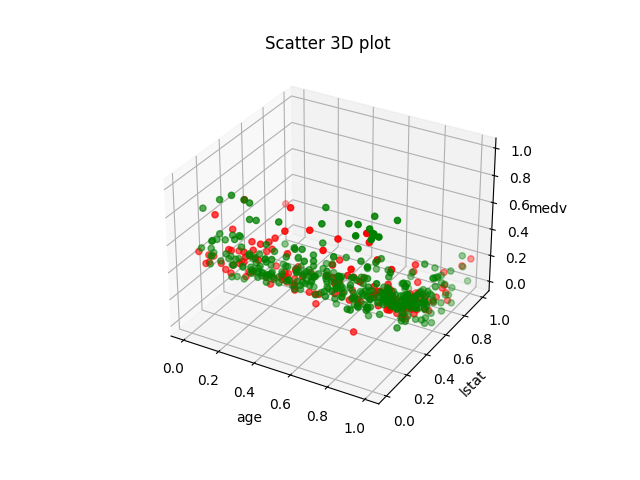

In [20]:
# 3D PLOT
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(trainX[:,1], trainX[:,2], trainY, color='green')
ax.scatter(testX[:,1], testX[:,2], testY, color='red')
ax.set_title('Scatter 3D plot')
ax.set_xlabel('age')
ax.set_ylabel('lstat')
ax.set_zlabel('medv')

In [21]:
def h(x, w):
  return np.sum(np.multiply(x, w))

In [22]:
def Error(y, x, w):
  m, = y.shape
  e = 0
  for j in range(m):
    sum = (float(y[j] - h(x[j,:], w))**2)/(2.0*m)
    e = e + sum
  return e

In [23]:
def derivada(x,y,params):
  #implementar las derivadas
  m, = y.shape
  r, c = x.shape

  # first derivative
  derivatives = np.array(
    [ sum([(y[i] - h(x[i,:],params))*-1 for i in range(m)])/(m*1.0) ]
  )
  
  for j in range(1, c):
    der = sum([(y[i] - h(x[i,:], params))*-x[i, j] for i in range(m)])/(m*1.0)
    derivatives = np.append(derivatives, der)
  
  return derivatives

In [24]:
def update(params, alfa, deriv):
  return params - alfa*deriv

In [25]:
arrL = []

def train(x,y,umbral, alfa):
  paramArr = np.array([np.random.rand() for i in range(len(x[0, :]))])     # k+1 parametros w0 + w1x1 + ... wkxk

  display(paramArr)
  
  L = Error(y, x, paramArr)     # print(f"L: {L}")
  
  i = 0
  while(L > umbral):
    derivatives = np.array(derivada(x, y, paramArr))
    # print(f"derivatives {derivatives}", end=" -> ")
    
    paramArr = update(paramArr ,alfa, derivatives) 
    # print(f"paramArr {paramArr}", end=" -> ")
    
    L = Error(y,x,paramArr) 
    # print(f"L: {L} ", end="")
    arrL.append(L)
    if i % 100 == 0:
      print(f"L: {L} ", end="")
    if i % 200 == 0:
      print()
    i = i + 1
    # time.sleep(2)
  print(f"\n{i} epochs")
  return paramArr

In [26]:
def test(x, y, w):
    print(f'Error: {Error(y, x, w)}')

    # 2D PLOT
    fig = plt.figure()
    plt.title("Error function along training")
    plt.ylabel("L")
    plt.xlabel("epochs")
    plt.plot(np.arange(1,len(arrL)+1), arrL)

    # 3D PLOT
    l_x = np.linspace(0,1,100)
    l_y = np.linspace(0,1,100)

    l_x, l_y = np.meshgrid(l_x, l_y)
    l_z = paramArr[0] + paramArr[1]*l_x + paramArr[2]*l_y

    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.scatter(x[:,1], x[:,2], y, color='green', alpha=0.3)
    ax.scatter(testX[:, 1], testX[:, 2], testY, color='red', alpha=0.4)
    ax.plot_surface(l_x, l_y, l_z, alpha=0.4, color="blue")
    ax.set_title(f'{round(paramArr[0], 3)} + {round(paramArr[1], 3)}*age + {round(paramArr[2], 3)}*lstat')
    ax.set_xlabel('age')
    ax.set_ylabel('lstat')
    ax.set_zlabel('mdev')
    ax.view_init(10, 45)

In [27]:
arrL = []
paramArr = train(trainX, trainY, 0.0099999, 0.05)
paramArr

array([0.21970115, 0.26463608, 0.52596842])

L: 0.06797462671578157 
L: 0.03384378448920405 L: 0.025256067091290177 
L: 0.020162111087573 L: 0.017029910295128726 
L: 0.015021359516867684 L: 0.013673858162933135 
L: 0.012728747210048932 L: 0.012038734132390523 
L: 0.011517832206726699 L: 0.011114201665010932 
L: 0.01079534333474894 L: 0.01053996763155041 
L: 0.010333481488104557 L: 0.01016544478599573 
L: 0.010028105988293694 
1525 epochs


array([ 0.60446226, -0.0226776 , -0.65535483])

Error: 0.009999023415449613


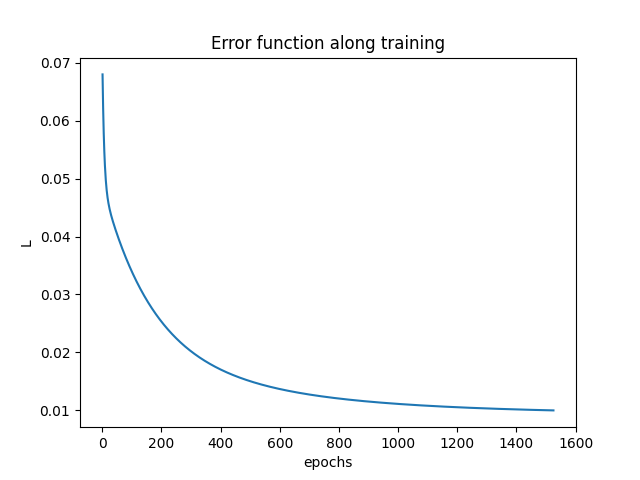

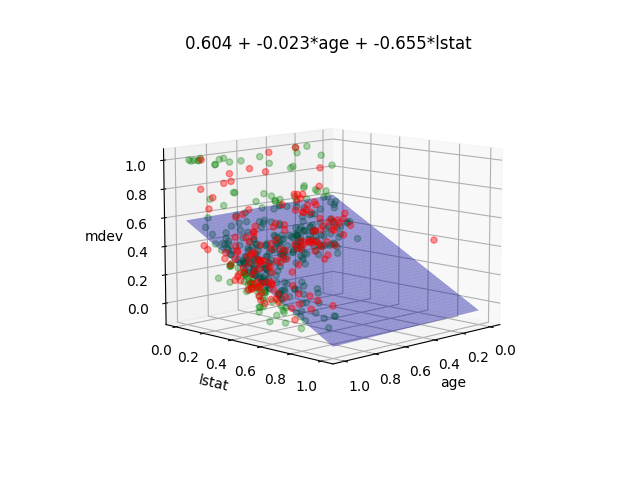

In [28]:
test(trainX, trainY, paramArr)